# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Movielens data querying and analysis using NoSQL Database

## Problem Statement

Using the Cassandra NoSQL database, explore the **Movielens** dataset and build a movie recommendation engine

## Learning Objectives

At the end of the mini-project, you will be able to :

* understand the concepts of NoSQL platforms
* implement the database connectivity using Cassandra
* create and insert data to the database
* perform querying, retrieving and analyzing the data from database

### Dataset

The dataset chosen for this mini-project is [Movielens Dataset](https://movielens.org/). The dataset describes movies and ratings from Movielens. It contains movies from year 1919 to 2000 of total 3883 movies. There are 6040 users who have rated one or more than one movie of total 1000209 ratings collected. Movielens is maintained by members of GroupLens Research at the University of Minnesota. There are 3 datasets given, and they are:

1. `data_movie.csv` that contains movies information:

* MovieId
* Title
* Genres

2. `data_rating.csv` that contains ratings of movies by users:

* UserId
* MovieId
* Rating

3. `data_users.csv` that contains users information:

* UserId
* Age
* Gender

## Information

#### NoSQL platforms

A NoSQL database provides a mechanism for storage and retrieval of data that is modeled in a form other than the tabular relations used in relational databases.

**Cassandra**

Apache Cassandra is a free and open-source, distributed, wide-column store, NoSQL database management system designed to handle large amounts of data across many commodity servers, providing high availability with no single point of failure. It is a NOSQL database developed by Facebook. It is a great database that allows you to effectively run queries on large amount of structured and semi structured data.

To know when you have to choose Cassandra as your database of choice, you need to have an understanding of CAP Theorem.

CAP theorem states that it is impossible for a distributed system to satisfy all three of these guarantees together, you need to leave one out.

- C is Consistency, means all nodes have the same data at the same time
- P is partition tolerance, means that in case of failure the system continues to operate
- A is availability , make sure every request receives a response

![img](https://developer.ibm.com/developer/default/tutorials/ba-set-up-apache-cassandra-architecture/images/figure1.png)

### Components of Cassandra

There are following components in the Cassandra

![img](https://www.guru99.com/images/cassandra/021116_0524_CassandraAr1.png)

**Node**
Node is the place where data is stored. It is the basic component of Cassandra.

**Data Center**
A collection of nodes are called data center. Many nodes are categorized as a data center.

**Cluster**
The cluster is the collection of many data centers.

**Commit Log**
Every write operation is written to Commit Log. Commit log is used for crash recovery.

**Mem-table**
After data written in Commit log, data is written in Mem-table. Data is written in Mem-table temporarily.

**SSTable**
When Mem-table reaches a certain threshold, data is flushed to an SSTable disk file.

### Data Replication

As hardware problem can occur or link can be down at any time during data process, a solution is required to provide a backup when the problem has occurred. So data is replicated for assuring no single point of failure.

Cassandra places replicas of data on different nodes based on these two factors.
- Where to place next replica is determined by the Replication Strategy.
- While the total number of replicas placed on different nodes is determined by the Replication Factor.

One Replication factor means that there is only a single copy of data while three replication factor means that there are three copies of the data on three different nodes.

## Grading = 10 Points

**Install the cassandra-driver**

In [ ]:
!pip install cassandra-driver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 31.4 MB/s eta 0:00:00


#### Importing Necessary Packages

In [ ]:
import pandas as pd
import cassandra
from cassandra.cluster import Cluster
from cassandra.auth import PlainTextAuthProvider
from matplotlib import pyplot as plt

In [ ]:
print(cassandra.__version__)

3.29.2


### Database connection (2 points)

**Astra Datastax login:** Please refer to this [document](https://cdn.iisc.talentsprint.com/CDS/DB_Connect_Docs/Datastax_Connect.pdf) for account creation on DataStax

**Connect the database and create keyspace:**

* Download Secure Connect Bundle zip file from Datastax [connect](https://docs.datastax.com/en/astra/docs/obtaining-database-credentials.html) section. Follow the instructions on the page
* Upload the `Secure-connect-XXXX.zip` file, which is downloaded from datastax.
* Generate the token and save the credentials from settings section.
    - Hint: Select role as `admin-user` and generate token
* Using the credentials generated in settings, specify the `client Id` and `Client Secret` to the variables below.

In [ ]:
#@title Download bundle zip
!wget -qq https://cdn.exec.talentsprint.com/static/cds/content/secure_connect_cds_mov_database.zip
!wget -qq https://cdn.exec.talentsprint.com/static/cds/content/data_movies.csv
!wget -qq https://cdn.exec.talentsprint.com/static/cds/content/data_ratings.csv
!wget -qq https://cdn.exec.talentsprint.com/static/cds/content/data_users.csv

In [ ]:
from google.colab import files
files.upload()

set the `Secure connect bundle zip file` path and specify the `clientID` and `Client_Secret`

Note: Credentials used are from CDS account on Datastax

**Database details:**

Database name: cds_mov_database

Namespace name: cds_mov

Collection name: cds_mov_collection

Collection name: cds_rating_collection

Collection name: cds_user_collection

zip_path = '/content/secure-connect-cds-mov-database.zip'

Client_ID = 'Your_Client_ID'

Client_Secret = 'Your_Client_Secret'

In [ ]:
from google.colab import userdata

zip_path = '/content/secure-connect-cds.zip'
Client_ID = userdata.get('clientId')
Client_Secret = userdata.get('clientSecret')

In [ ]:
Client_ID, Client_Secret

('GwKJDpIaugCXWKBOEsQtWBvw',
 'tqH.NbN2eyicP3DiOWeU3_9znxbPd9sf69cB-zN0+TPes4qZcHuaPXMjKySNE.rwqrKR51yFE_YR7--542OgSGqC0Zbsb_e..2kpMSMIDrCzruc5mXZCtDl_F_wCvAXX')

#### Create a Cluster instance to connect to your Astra database.

You will typically have one instance of Cluster for each Cassandra cluster you want to interact with. Create a session object using the cluster.

**Hint:** Refer Python documentation under Connect.

In [ ]:
cloud_config= {
   'secure_connect_bundle': zip_path
}
auth_provider = PlainTextAuthProvider(Client_ID,
                                      Client_Secret)
cluster = Cluster(cloud=cloud_config, auth_provider=auth_provider)
session = cluster.connect()

#### Verifying the database connection

execute a simple query and verify the database connection

In [ ]:
session?

In [ ]:
# YOUR CODE HERE
query = 'SELECT table_name FROM system_schema.tables WHERE keyspace_name = \'movielens\''
rows = session.execute(query)
for row in rows:
    print(row)

Row(table_name='data_movies')
Row(table_name='data_ratings')
Row(table_name='data_users')


#### Setting the Key Space

A keyspace is the top-level database object that controls the replication for the object it contains at each datacenter in the cluster. Keyspaces contain tables, materialized views and user-defined types, functions and aggregates. Typically, a cluster has one keyspace per application. Since replication is controlled on a per-keyspace basis, store data with different replication requirements (at the same datacenter) in different keyspaces.

Before creating tables and inserting data let's create and set the keyspace

* we can create keyspace manually on Datastax dashboard or also using the CQL command. (use lowercase to avoid errors)

    * [Hint](https://docs.datastax.com/en/cql-oss/3.x/cql/cql_reference/cqlCreateKeyspace.html)

* once the keyspace is created successfully, set the keyspace using the command `set_keyspace()`

In [ ]:
# YOUR CODE HERE
session.set_keyspace('movielens')

### Insert the data into Database (1 point)

To insert the data into database, we can create a table in keyspace and insert the data by using CQL command or we can directly upload the data on the datstax dashboard using [Astra Dataloader](https://docs.datastax.com/en/astra/docs/develop/dev-upload-data.html)

As there is huge amount of data, insertion of data using CQL commands may take time, preferable method is Astra Dataloader.

* Download the below mentioned 3 datasets and upload to Datastax Astra dashboard using Astra Dataloader
    * [data_movies](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_movies.csv)
    * [data_ratings](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_ratings.csv)
    * [data_users](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_users.csv)
    
while uploading data using Datastax Astra dataloader you may encounter the below error message due to formatting issues or bulk data. In that case, click on upload button for second time for data upload.
![img](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_upload_error.JPG)

Note: Cassandra also handles non-SQL data formats such as JSON (see [insert JSON data](https://docs.datastax.com/en/cql-oss/3.3/cql/cql_using/useInsertJSON.html)). However for the purpose of this Mini-project, we are using a tabular data format (.csv).

### Loading the data


In [ ]:
# YOUR CODE HERE
data_movies = pd.read_csv('data_movies.csv')

In [ ]:
# YOUR CODE HERE
data_ratings = pd.read_csv('data_ratings.csv')

In [ ]:
# YOUR CODE HERE
data_users = pd.read_csv('data_users.csv')

In [ ]:
data_ratings

,movieid,rating,userid
0,2929,4,1119
1,480,3,2918
2,3536,5,5589
3,3181,3,4277
4,2916,3,4708
...,...,...,...
1000204,2078,2,5535
1000205,1427,2,3151
1000206,2072,3,4312
1000207,3555,5,2265


### Querying the database (2 points)

* Select First 10 rows of the data_movies table
* How many Users have watched the movie  `'Contact (1997)'` with MovieId = 1584
* Select the count of teenage male users

**Note:** For syntax related issues, try the **CQLConsole** on Datastax dashboard

**Hint:** [CQL command for select](https://docs.datastax.com/en/cql-oss/3.3/cql/cql_using/useQueryColumnsSort.html)

In [ ]:
from cassandra.query import BatchStatement

def perform_batch_insert(batch_insert_statement, data, batch_size=1000):
    batch_insert_prep_statement = session.prepare(batch_insert_statement)
    batch_insert_prep_statement.consistency_level = 'LOCAL_QUORUM'
    batch_num = 0
    for i in range(0, len(data), batch_size):
        batch = BatchStatement()
        print(f"Inserting batch number {batch_num} from {i} to {i + batch_size}")
        for row in data[i : i + batch_size]:
            batch.add(batch_insert_prep_statement, row)
        # No need to wait for previous one to complete
        session.execute_async(batch)
        batch_num += 1

#### Creating the data_movies table

In [ ]:
# Use the following SQL query:
query = """CREATE TABLE  IF NOT EXISTS data_movies (movieid INT,
                                                title TEXT,
                                                genres TEXT,
                                                PRIMARY KEY (movieid))""";

# YOUR CODE HERE
session.execute(query)

In [ ]:
data_movies_cols = "movieid, title, genres"
batchmovies_insert_statement = f"INSERT INTO movielens.data_movies ({data_movies_cols}) VALUES (?, ?, ?)"
batch_insert_prep_statement = session.prepare(batchmovies_insert_statement)

# Example data to bulk insert
datamovies_to_insert = [(row['movieid'], row['title'], row['genres']) for (i,row) in data_movies.iterrows()]

In [ ]:
len(datamovies_to_insert)

3883

In [ ]:
perform_batch_insert(batchmovies_insert_statement, datamovies_to_insert, batch_size=100)

**Please note that the above code cell will take around 6 mins 30 secs to complete execution on CPU**

#### Creating the data_ratings table

In [ ]:
# Use the following SQL query:
query = """CREATE TABLE  IF NOT EXISTS data_ratings (movieid INT,
                                                rating INT,
                                                userid INT,
                                                PRIMARY KEY (movieid, userid)); """
session.execute(query)

In [ ]:
data_ratings_cols = "movieid, userid, rating"
batchratings_insert_statement = f"INSERT INTO movielens.data_ratings ({data_ratings_cols}) VALUES (?, ?, ?)"
batch_insert_prep_statement = session.prepare(batchratings_insert_statement)

# Example data to bulk insert
data_to_insert = [(row['movieid'], row['userid'], row['rating']) for (i,row) in data_ratings.iterrows()]

In [ ]:
%time perform_batch_insert(batchratings_insert_statement, data_to_insert, batch_size=1000)

Inserting batch number 0 from 0 to 1000
Inserting batch number 1 from 1000 to 2000
Inserting batch number 2 from 2000 to 3000
Inserting batch number 3 from 3000 to 4000
Inserting batch number 4 from 4000 to 5000
Inserting batch number 5 from 5000 to 6000
Inserting batch number 6 from 6000 to 7000
Inserting batch number 7 from 7000 to 8000
Inserting batch number 8 from 8000 to 9000
Inserting batch number 9 from 9000 to 10000
Inserting batch number 10 from 10000 to 11000
Inserting batch number 11 from 11000 to 12000
Inserting batch number 12 from 12000 to 13000
Inserting batch number 13 from 13000 to 14000
Inserting batch number 14 from 14000 to 15000
Inserting batch number 15 from 15000 to 16000
Inserting batch number 16 from 16000 to 17000
Inserting batch number 17 from 17000 to 18000
Inserting batch number 18 from 18000 to 19000
Inserting batch number 19 from 19000 to 20000
Inserting batch number 20 from 20000 to 21000
Inserting batch number 21 from 21000 to 22000
Inserting batch numb

**Please note that the above code cell will take around 8 mins 26 secs to complete execution on CPU**

# Group 6 Comment

Using batch insert and async exec, 1 million records could be inserted under 13 sec.

#### Creating the data_users table

In [ ]:
# Use the following SQL query:
query = """CREATE TABLE  IF NOT EXISTS data_users (userid INT,
                                                gender TEXT,
                                                age INT,
                                                PRIMARY KEY (userid)); """
session.execute(query)

In [ ]:
data_users_cols = "userid, gender, age"
batchusers_insert_statement = f"INSERT INTO movielens.data_users ({data_users_cols}) VALUES (?, ?, ?)"
batch_insert_prep_statement = session.prepare(batchusers_insert_statement)

# Example data to bulk insert
datausers_to_insert = [(row['userid'], row['gender'], row['age']) for (i,row) in data_users.iterrows()]

In [ ]:
len(datausers_to_insert)

6040

In [ ]:
%time perform_batch_insert(batchusers_insert_statement, datausers_to_insert, batch_size=100)

Inserting batch number 0 from 0 to 100
Inserting batch number 1 from 100 to 200
Inserting batch number 2 from 200 to 300
Inserting batch number 3 from 300 to 400
Inserting batch number 4 from 400 to 500
Inserting batch number 5 from 500 to 600
Inserting batch number 6 from 600 to 700
Inserting batch number 7 from 700 to 800
Inserting batch number 8 from 800 to 900
Inserting batch number 9 from 900 to 1000
Inserting batch number 10 from 1000 to 1100
Inserting batch number 11 from 1100 to 1200
Inserting batch number 12 from 1200 to 1300
Inserting batch number 13 from 1300 to 1400
Inserting batch number 14 from 1400 to 1500
Inserting batch number 15 from 1500 to 1600
Inserting batch number 16 from 1600 to 1700
Inserting batch number 17 from 1700 to 1800
Inserting batch number 18 from 1800 to 1900
Inserting batch number 19 from 1900 to 2000
Inserting batch number 20 from 2000 to 2100
Inserting batch number 21 from 2100 to 2200
Inserting batch number 22 from 2200 to 2300
Inserting batch num

**Please note that the above code cell will take around 10 mins 11 secs to complete execution on CPU**

* Select First 10 rows of the data_movies table

In [ ]:
# YOUR CODE HERE
query = 'SELECT * FROM movielens.data_movies LIMIT 10;'
rows = session.execute(query)
for row in rows:
    print(row)

Row(movieid=3372, genres='Action|War', title='Bridge at Remagen, The (1969)')
Row(movieid=1584, genres='Drama|Sci-Fi', title='Contact (1997)')
Row(movieid=2731, genres='Drama', title='400 Blows, The (Les Quatre cents coups) (1959)')
Row(movieid=2713, genres='Horror|Thriller', title='Lake Placid (1999)')
Row(movieid=769, genres='Documentary', title='Marlene Dietrich: Shadow and Light (1996)')
Row(movieid=1863, genres='Comedy', title='Major League: Back to the Minors (1998)')
Row(movieid=2453, genres='Drama|Fantasy', title='Boy Who Could Fly, The (1986)')
Row(movieid=2302, genres='Comedy', title='My Cousin Vinny (1992)')
Row(movieid=3733, genres='Drama', title='Paper Chase, The (1973)')
Row(movieid=1765, genres='Crime|Drama', title='Letter From Death Row, A (1998)')


In [ ]:
# YOUR CODE HERE
query = 'SELECT * FROM movielens.data_ratings LIMIT 100;'
rows = session.execute(query)
for row in rows:
    print(row)

* How many Users have watched the movie 'Contact (1997)' with MovieId = 1584

**Hint:** Use the following query command.

"SELECT count(*) FROM cds_mov.data_ratings WHERE movieid=1584 ALLOW FILTERING;"

In [ ]:
# YOUR CODE HERE
query = 'SELECT count(*) FROM movielens.data_ratings WHERE movieid=1584 ALLOW FILTERING;'
rows = session.execute(query)
for row in rows:
    print(row)

Row(count=1382)


* Select the count of teenage male users

**Hint:** Use the following query command.

"""select count(*) from cds_mov.data_users where age<20 and gender='M' allow filtering;"""

In [ ]:
# YOUR CODE HERE
query = 'SELECT count(*) from movielens.data_users where age < 20 and gender=\'M\' allow filtering;'
rows = session.execute(query)
for row in rows:
    print(row)

Row(count=949)


* Select the count of movies with Top rating from the entire ratings table

In [ ]:
# YOUR CODE HERE
query = 'SELECT count(*) FROM movielens.data_ratings WHERE rating=5 ALLOW FILTERING;'
rows = session.execute(query)
for row in rows:
    print(row)

Row(count=226310)


* Select the count of movies, ONLY in Comedy genre from the entire data_movies table

In [ ]:
# YOUR CODE HERE

query = 'SELECT count(*) FROM movielens.data_movies WHERE genres=\'Comedy\' ALLOW FILTERING;'
rows = session.execute(query)
for row in rows:
    print(row)

Row(count=521)


### Visualizing the Data (2 points)

Retrieve the data using CQL queries and visualize using matplotlib

* Visualize the frequencies of movie genres from the entire data

**Hint:** Use the following query

query = 'select genres from cds_mov.data_movies'

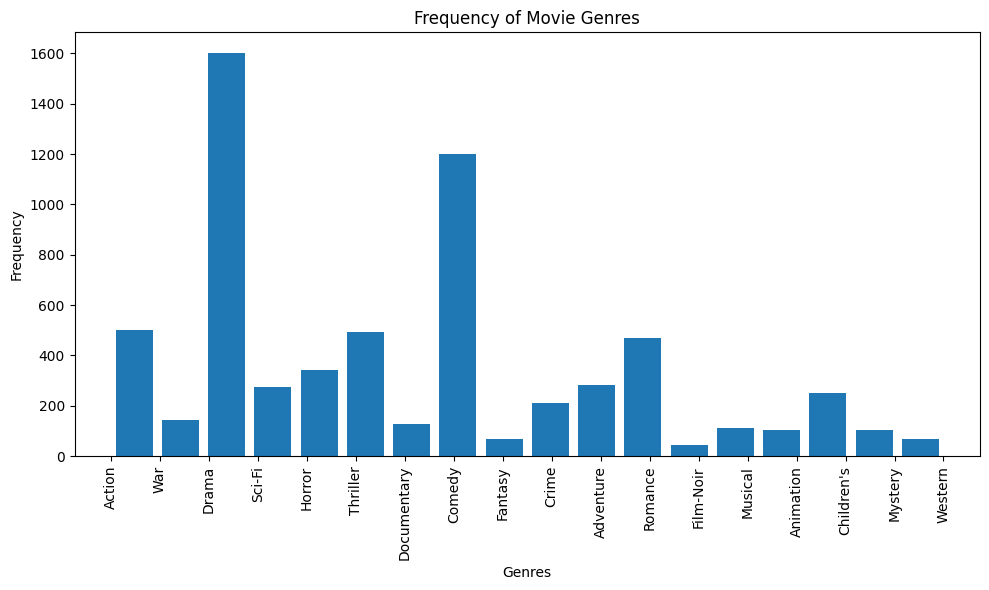

In [ ]:
# YOUR CODE HERE

query = 'SELECT genres from movielens.data_movies'
rows = session.execute(query)
genres = [row.genres.split('|') for row in rows]

# Process the genres data to count frequencies
# genre_list = [genre.split('|') for genre in genres]
flat_genre_list = [item for sublist in genres for item in sublist]

# Visualize hist plot
plt.figure(figsize=(10, 6))
plt.hist(flat_genre_list, bins=len(set(flat_genre_list)), rwidth=0.8)
plt.xticks(rotation=90)
plt.xlabel("Genres")
plt.ylabel("Frequency")
plt.title("Frequency of Movie Genres")
plt.tight_layout()
plt.show()

* Visualize the bar plot showing no.of movies released in a particular year

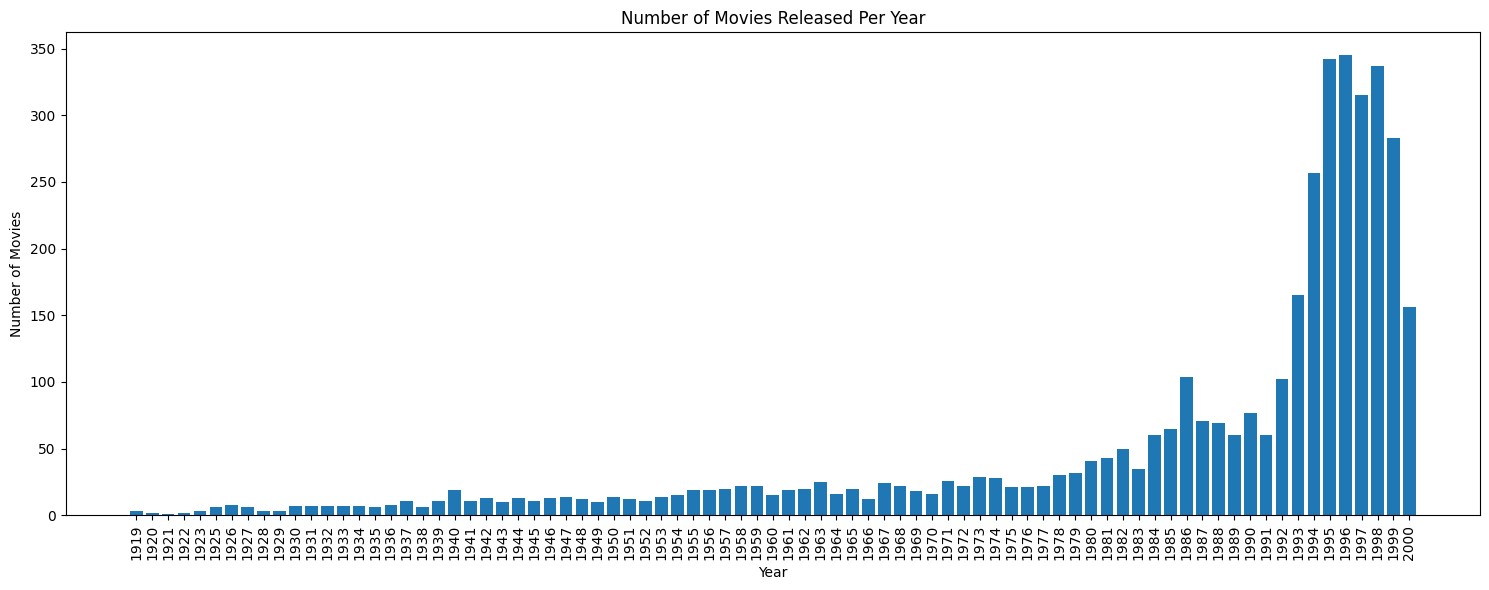

In [ ]:
import re
from collections import Counter
# YOUR CODE HERE
query = 'SELECT title FROM movielens.data_movies ALLOW filtering;'
rows = session.execute(query)

# Extract year from the title
years = [re.search(r'\((\d{4})\)', row.title).group(1) for row in rows if re.search(r'\((\d{4})\)', row.title)]

# Count the frequency of each year
year_counts = Counter(years)

# Sort the years chronologically
sorted_years = sorted(year_counts.keys())
sorted_counts = [year_counts[year] for year in sorted_years]

# Visualize bar plot
plt.figure(figsize=(15, 6))
plt.bar(sorted_years, sorted_counts, width=0.8)
plt.xticks(rotation=90)
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Number of Movies Released Per Year")
plt.tight_layout()
plt.show()

* Depict the plot of Age groups ratio who are active in watching movies

**Hint:** Use the following query.

query = 'select age from cds_mov.data_users;'

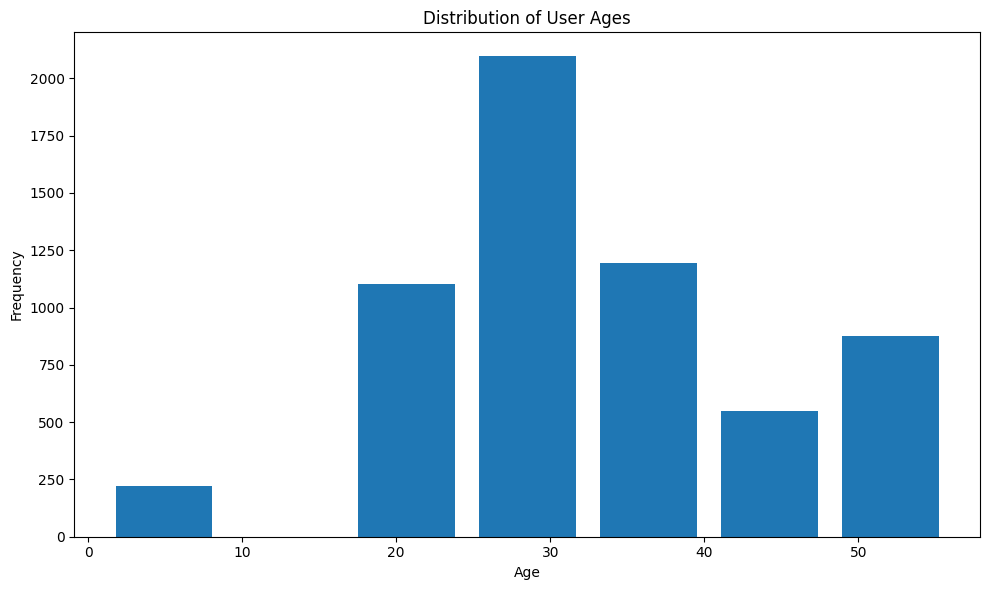

In [ ]:
# YOUR CODE HERE
query = 'SELECT age from movielens.data_users;'
rows = session.execute(query)

# Depict plot
ages = [row.age for row in rows]
plt.figure(figsize=(10, 6))
plt.hist(ages, bins=len(set(ages)), rwidth=0.8)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of User Ages")
plt.tight_layout()
plt.show()

## Retrieve genre data

### Subtask:
Fetch the movie titles and their corresponding genres from the database.


**Reasoning**:
Fetch the movie titles and genres from the database to prepare for genre-based analysis.



In [ ]:
query = 'SELECT title, genres FROM movielens.data_movies ALLOW FILTERING;'
rows = session.execute(query)

## Prepare data for clustering

### Subtask:
Process the genre strings to create a suitable representation for clustering, possibly using techniques like one-hot encoding or TF-IDF.


**Reasoning**:
Process the genre data to create a suitable representation for clustering by extracting titles and genres, splitting genres, finding unique genres, and creating binary genre vectors.



In [ ]:
titles = []
genres_list = []
for row in rows:
    titles.append(row.title)
    genres_list.append(row.genres.split('|'))

all_genres = sorted(list(set([genre for sublist in genres_list for genre in sublist])))

genre_representations = []
for movie_genres in genres_list:
    representation = [1 if genre in movie_genres else 0 for genre in all_genres]
    genre_representations.append(representation)

import numpy as np
genre_matrix = np.array(genre_representations)

In [ ]:
genre_matrix.shape

(3883, 18)

## Apply clustering algorithm

### Subtask:
Use a clustering algorithm (e.g., K-Means, DBSCAN) to group movies based on their genre representations.


**Reasoning**:
Instantiate and fit a KMeans model to the genre matrix to cluster movies based on genres.



In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=20, random_state=42, n_init=10) # Set n_init explicitly
cluster_labels = kmeans.fit_predict(genre_matrix)

## Visualize clusters

### Subtask:
Reduce the dimensionality of the genre data (if necessary) and create a scatter plot or other visualization to show the clusters.


**Reasoning**:
Reduce the dimensionality of the genre matrix using PCA and then visualize the clusters using a scatter plot.



In [ ]:
plt.scatter?

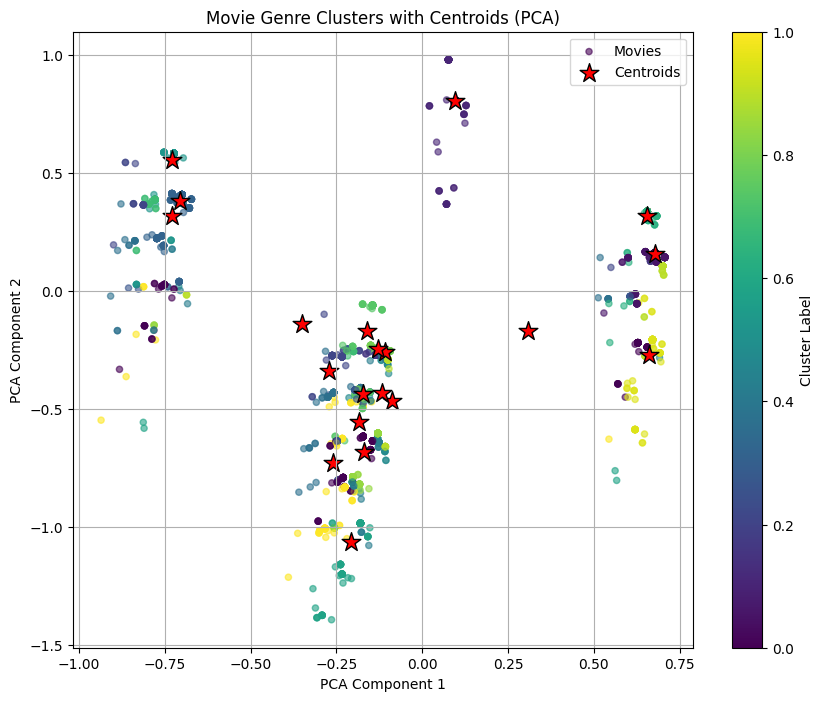

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Re-fit KMeans to get cluster_centers_ if it wasn't run again after modification
if 'kmeans' not in locals() or not hasattr(kmeans, 'cluster_centers_'):
    kmeans = KMeans(n_clusters=20, random_state=42, n_init=10) # Set n_init explicitly
    cluster_labels = kmeans.fit_predict(genre_matrix)


pca = PCA(n_components=2)
pca_components = pca.fit_transform(genre_matrix)

# Transform cluster centroids using the fitted PCA model
centroids = kmeans.cluster_centers_
pca_centroids = pca.transform(centroids)


plt.figure(figsize=(10, 8))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=cluster_labels, cmap='viridis', s=20, alpha=0.6, label='Movies')
plt.scatter(pca_centroids[:, 0], pca_centroids[:, 1], marker='*', s=200, c='red', edgecolors='black', label='Centroids') # Plot centroids
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Movie Genre Clusters with Centroids (PCA)')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.legend() # Add legend to distinguish movies and centroids
plt.show()

# Group 6 comment

Based on the KMeans scatter plot in cell bbfe5a75 and the cluster interpretations in cell 91a06471, here are some conclusions:

The scatter plot visually demonstrates that KMeans was able to group movies into 20 distinct clusters based on their genre combinations.

The separation of points in the scatter plot suggests that movies with similar genre profiles tend to be grouped together.

Clusters indicate that genre information is a significant factor in determining the similarity between movies, as captured by the KMeans algorithm.

The visualization and subsequent analysis of the clusters help in understanding the underlying structure of the movie dataset based on genre.

In essence, the scatter plot provides a visual confirmation that movies with similar genres are clustered together, supporting the use of genre information for grouping movies.

## Interpret clusters

### Subtask:
Analyze the movies within each cluster to understand the genre combinations that form the groups.


**Reasoning**:
Create a pandas DataFrame with movie titles, genres, and cluster labels, then iterate through the clusters, filter the DataFrame for each cluster, and print example movies to analyze genre combinations.



In [ ]:
movies_df = pd.DataFrame({'title': titles, 'genres': genres_list, 'cluster': cluster_labels})

for cluster_id in range(kmeans.n_clusters):
    cluster_movies = movies_df[movies_df['cluster'] == cluster_id]
    print(f"Cluster {cluster_id}:")
    display(cluster_movies.head())
    print("\n")

Cluster 0:


,title,genres,cluster
0,"Bridge at Remagen, The (1969)","[Action, War]",0
31,Braveheart (1995),"[Action, Drama, War]",0
33,"Towering Inferno, The (1974)","[Action, Drama]",0
37,"Hunted, The (1995)",[Action],0
40,Loaded Weapon 1 (1993),"[Action, Comedy]",0




Cluster 1:


,title,genres,cluster
1,Contact (1997),"[Drama, Sci-Fi]",1
2,"400 Blows, The (Les Quatre cents coups) (1959)",[Drama],1
6,"Boy Who Could Fly, The (1986)","[Drama, Fantasy]",1
8,"Paper Chase, The (1973)",[Drama],1
15,Margaret's Museum (1995),[Drama],1




Cluster 2:


...

,title,genres,cluster
9,"Letter From Death Row, A (1998)","[Crime, Drama]",17
60,"Young Poisoner's Handbook, The (1995)",[Crime],17
183,Angel on My Shoulder (1946),"[Crime, Drama]",17
192,Turn It Up (2000),"[Crime, Drama]",17
215,Killer: A Journal of Murder (1995),"[Crime, Drama]",17




Cluster 18:


,title,genres,cluster
34,Public Access (1993),"[Drama, Thriller]",18
52,Heavenly Creatures (1994),"[Drama, Fantasy, Romance, Thriller]",18
80,"Talented Mr. Ripley, The (1999)","[Drama, Mystery, Thriller]",18
86,Betrayed (1988),"[Drama, Thriller]",18
165,"Green Mile, The (1999)","[Drama, Thriller]",18




Cluster 19:


,title,genres,cluster
10,Men in Black (1997),"[Action, Adventure, Comedy, Sci-Fi]",19
12,Brazil (1985),[Sci-Fi],19
64,Night of the Comet (1984),"[Action, Horror, Sci-Fi]",19
93,It Came from Outer Space (1953),[Sci-Fi],19
96,X-Men (2000),"[Action, Sci-Fi]",19


### Analyzing the Data (3 points)

Analyzing the correlation between the movies records, implement a function to recommend movies based on search term

* Retrieve all the data from ratings table

**Hint:** Use the following query.

query = 'select * from cds_mov.data_ratings;'

In [ ]:
# YOUR CODE HERE
query = 'SELECT * from movielens.data_ratings;'
rows = session.execute(query)
ratings_data = rows.all()

In [ ]:
ratings_data

* Create a movie matrix by applying pivot table with the above retrieved ratings data

* use `pd.pivot_table` with index = `userid`, columns = `movieid` and Values = `rating`

 **Hint:** create a dataframe with above retrieved ratings data to apply pivot table

In [ ]:
# YOUR CODE HERE
# Create a DataFrame from the retrieved ratings data
ratings_df = pd.DataFrame(ratings_data)

# Create the movie matrix using pivot_table
movie_matrix = pd.pivot_table(ratings_df, index='userid', columns='movieid', values='rating')

# Display the first few rows of the movie matrix
display(movie_matrix.head())

movieid,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userid,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Define a function named `recommend_movies()` which will take a movieid as argument and return the top 5 similar movieid's

    * Considering the argument (movieid) as search item collect the particular row data
    
    * Using movie matrix calculate correlation between movie search Item data and all the remaining data
    
        * Hint: [corr_with()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corrwith.html)
        
    * Sort the result by ascending order and return the top 5 items

In [ ]:
def recommend_movie(movieId):
    # Considering the argument (movieid) as search item collect the particular row data
    movie_ratings = movie_matrix[movieId]

    # Using movie matrix calculate correlation between movie search Item data and all the remaining data
    similar_movies = movie_matrix.corrwith(movie_ratings)

    # Create a DataFrame of similar movies and drop the original movie
    corr_movies = pd.DataFrame(similar_movies, columns=['correlation'])
    corr_movies.dropna(inplace=True)
    corr_movies = corr_movies.join(data_movies.set_index('movieid')['title'])

    # Sort the result by descending order and return the top 5 items (excluding the input movie itself)
    sorted_corr_movies = corr_movies.sort_values('correlation', ascending=False)
    return sorted_corr_movies.head(6).iloc[1:] # Exclude the movie itself and get top 5

In [ ]:
recommend_movie(71)

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,correlation,title
movieid,,
2275,1.0,Six-String Samurai (1998)
100,1.0,City Hall (1996)
3739,1.0,Trouble in Paradise (1932)
71,1.0,Fair Game (1995)
2168,1.0,Dance with Me (1998)


* write a query to get MovieId of a Title (your choice) and the result MovieId as a search item by calling the above defined function

In [ ]:
# YOUR CODE HERE
query = 'SELECT movieid, title FROM movielens.data_movies where title = \'City Hall (1996)\' ALLOW filtering;'
rows = session.execute(query)

movieid = rows[0].movieid
print(movieid)

recommended_movies_df = recommend_movie(movieid)
recommended_movies_df.head()

/tmp/ipython-input-1795117772.py:5: DeprecationWarning: ResultSet indexing support will be removed in 4.0. Consider using ResultSet.one() to get a single row.
  movieid = rows[0].movieid
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


100


,correlation,title
movieid,,
3806,1.0,MacKenna's Gold (1969)
98,1.0,Shopping (1994)
2292,1.0,Overnight Delivery (1996)
1585,1.0,Love Serenade (1996)
2209,1.0,Young and Innocent (1937)


* Now taking the result of top 5 items (MovieId's) write a query to retrieve the Movie title from movies table

In [ ]:
# YOUR CODE HERE
# Get the movieids from the index of the recommended_movies_df DataFrame and convert to a list
recommended_movie_ids = recommended_movies_df.index.tolist()

query = f'SELECT title, genres FROM movielens.data_movies where movieid IN {tuple(recommended_movie_ids)}'
rows = session.execute(query)

print("Recommended Movie list:")
for row in rows:
    print(row.title, row.genres)

Recommended Movie list:
Shopping (1994) Action|Thriller
Love Serenade (1996) Comedy
Young and Innocent (1937) Crime|Thriller
Overnight Delivery (1996) Romance
MacKenna's Gold (1969) Western


In [ ]:
def recommend_movie_in_cluster(movieId):
    # Find the cluster of the input movie
    movie_info = data_movies[data_movies['movieid'] == movieId].iloc[0]
    movie_title = movie_info['title']
    movie_genres = movie_info['genres']
    movie_cluster = movies_df[movies_df['title'] == movie_title]['cluster'].iloc[0]

    print(f"Input Movie: {movie_title} (ID: {movieId})")
    print(f"Input Movie Genres: {movie_genres}")
    print(f"Movie Cluster: {movie_cluster}")

    # Filter the movie matrix and data_movies for the specific cluster
    cluster_data_movies = data_movies[movies_df['cluster'] == movie_cluster].copy() # Use .copy() to avoid SettingWithCopyWarning
    cluster_movie_ids = cluster_data_movies['movieid'].tolist()

    # Filter cluster_movie_ids to only include movie IDs present in movie_matrix columns
    valid_cluster_movie_ids = [mid for mid in cluster_movie_ids if mid in movie_matrix.columns]

    cluster_movie_matrix = movie_matrix[valid_cluster_movie_ids]

    # Considering the argument (movieid) as search item collect the particular row data
    if movieId not in cluster_movie_matrix.columns:
        print(f"MovieId {movieId} not found in the ratings data for its cluster.")
        return pd.DataFrame() # Return empty DataFrame if the movie is not in the filtered matrix

    movie_ratings = cluster_movie_matrix[movieId]

    # Using movie matrix calculate correlation between movie search Item data and all the remaining data
    similar_movies = cluster_movie_matrix.corrwith(movie_ratings)

    # Create a DataFrame of similar movies and drop the original movie
    corr_movies = pd.DataFrame(similar_movies, columns=['correlation'])
    corr_movies.dropna(inplace=True)
    corr_movies = corr_movies.join(cluster_data_movies.set_index('movieid')[['title', 'genres']])


    # Sort the result by descending order and return the top 5 items (excluding the input movie itself)
    sorted_corr_movies = corr_movies.sort_values('correlation', ascending=False)
    return sorted_corr_movies.head(6).iloc[1:] # Exclude the movie itself and get top 5

In [ ]:
recommended_movies_in_cluster = recommend_movie_in_cluster(71)
display(recommended_movies_in_cluster)

Input Movie: Fair Game (1995) (ID: 71)
Input Movie Genres: Action
Movie Cluster: 0


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,correlation,title,genres
movieid,,,
3781,1.000000,Shaft in Africa (1973),Action|Crime
3805,1.000000,Knightriders (1981),Action|Adventure|Drama
3139,1.000000,Tarzan the Fearless (1933),Action|Adventure
71,1.000000,Fair Game (1995),Action
3782,0.944911,Shaft's Big Score! (1972),Action|Crime


**Close the session**

In [ ]:
# YOUR CODE HERE
session.shutdown()
cluster.shutdown()

## Group 6 Summary:

### Data Analysis Key Findings

*   The K-Means algorithm was applied to group movies based on their genre representations, resulting in 20 distinct clusters.
*   Principal Component Analysis (PCA) was used to reduce the dimensionality of the genre data to 2 components for visualization.
*   A scatter plot was generated to visualize the 20 movie genre clusters in a 2D space.
*   Analysis of movies within each cluster revealed patterns of genre combinations, such as clusters dominated by specific genres (e.g., Drama, Comedy, Documentary) and clusters containing various genre mixes (e.g., Action/Adventure, Sci-Fi/Thriller, Musical/Comedy).

### Insights or Next Steps

*   The visualization effectively shows distinct groupings of movies based on their genre profiles, suggesting that genre combinations are a strong indicator for movie similarity.
*   Further analysis could involve examining the centroids of each cluster to identify the most representative genre combinations for each group or using silhouette scores to evaluate the quality of the clustering.


## Experiment

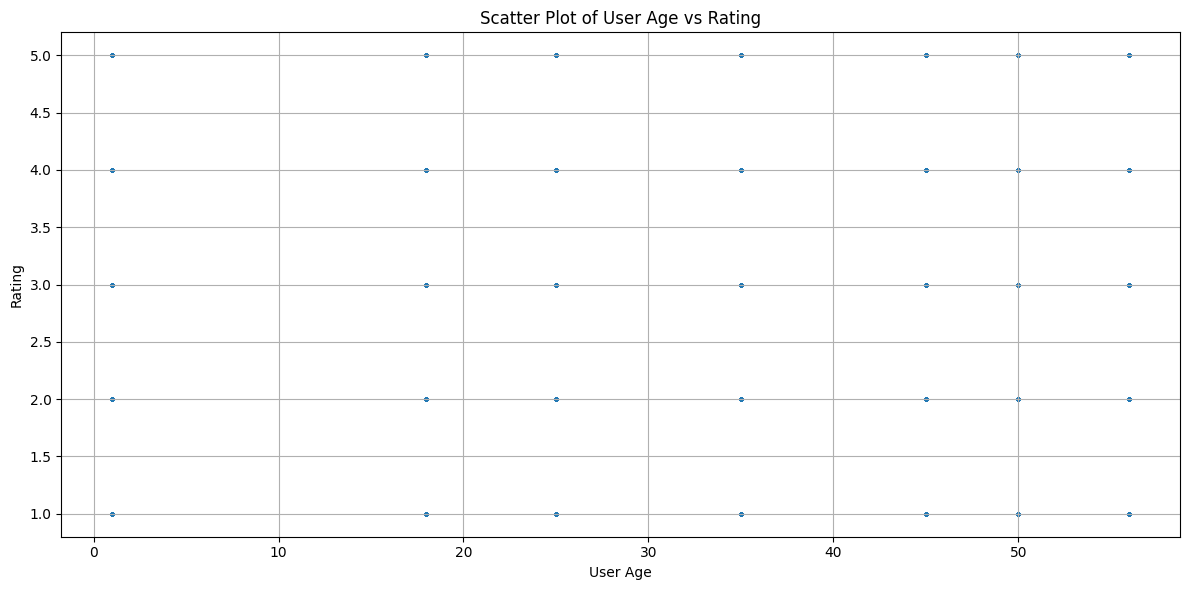

In [ ]:
# Retrieve user age data asynchronously
query_users = 'SELECT userid, age FROM movielens.data_users ALLOW FILTERING;'
future_users = session.execute_async(query_users)

# Retrieve rating data asynchronously
query_ratings = 'SELECT userid, rating FROM movielens.data_ratings ALLOW FILTERING;'
future_ratings = session.execute_async(query_ratings)

# Wait for both queries to complete and get the results
rows_users = future_users.result()
rows_ratings = future_ratings.result()

# Convert the data to pandas DataFrames
user_age_data = [{'userid': row.userid, 'age': row.age} for row in rows_users]
user_age_df = pd.DataFrame(user_age_data)

user_rating_data = [{'userid': row.userid, 'rating': row.rating} for row in rows_ratings]
user_rating_df = pd.DataFrame(user_rating_data)

# Merge the two DataFrames on userid
merged_df = pd.merge(user_rating_df, user_age_df, on='userid')

# Create the scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(merged_df['age'], merged_df['rating'], alpha=0.1, s=5) # Use smaller markers and lower alpha for density
plt.xlabel("User Age")
plt.ylabel("Rating")
plt.title("Scatter Plot of User Age vs Rating")
plt.grid(True)
plt.tight_layout()
plt.show()